# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

print("Number of classes:", len(class_names))
print("Class names:", class_names)


# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

# Convert training and test labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Verify the new shapes
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)



Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of classes: 10
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Training labels shape: (60000, 10)
Test labels shape: (10000, 10)


X_train shape: (60000, 28, 28)
60,000 training images.
Each image is 28 × 28 pixels.
Images are grayscale (one color channel).

y_train shape: (60000,)
One label for each of the 60,000 training images.
Labels are integers from 0 to 9, representing the clothing categories.

X_test shape: (10000, 28, 28)
10,000 images reserved for testing the model.
Each image is also 28 × 28 pixels.

y_test shape: (10000,)
One label for each test image.


Before conversion:
y_train.shape = (60000,)

y_test.shape = (10000,)

Each label is a single integer between 0 and 9.

After one-hot encoding:
y_train.shape = (60000, 10)

y_test.shape = (10000, 10)

Each label becomes a vector of length 10, with a 1 at the index corresponding to the correct class and 0s elsewhere.

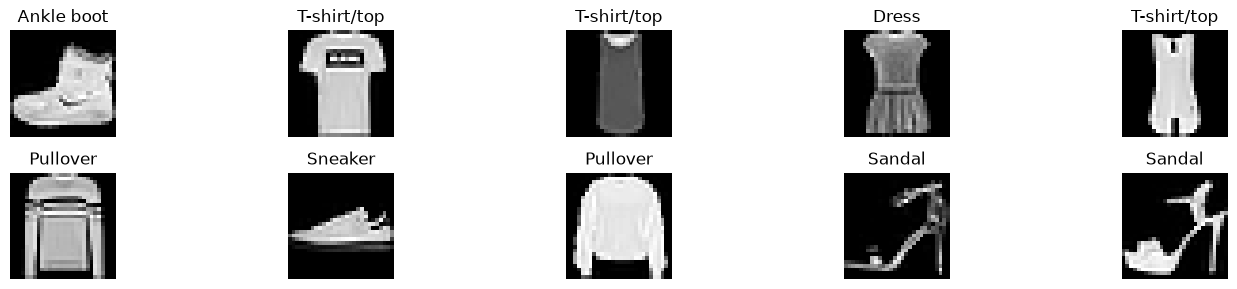

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected

# Display the first 10 training images
plt.figure(figsize=(15, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[np.argmax(y_train[i])])  # Use np.argmax because labels are one-hot encoded
    plt.axis('off')

plt.tight_layout()
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

The Fashion MNIST dataset looks as expected. It contains 60,000 training images and 10,000 test images, with each image represented as a 28 × 28 grayscale array. After normalization, the pixel values range from 0 to 1, confirming that the preprocessing step was completed successfully. Displaying several sample images with their corresponding labels showed that the labels matched the clothing items, indicating that the dataset has been loaded and encoded correctly.

The image quality is relatively low because each image has a resolution of only 28 × 28 pixels. Although the main shapes and outlines of the clothing items are visible, fine details such as textures, logos, or stitching are not distinguishable. Some classes, such as Shirt, T-shirt/top, Pullover, and Coat, appear visually similar, which may make them more difficult for a machine learning model to classify accurately.

One limitation of the dataset is that the low resolution can lead to ambiguity between similar clothing categories. In addition, all images are grayscale, so color information is unavailable, which could otherwise help distinguish certain items. Also some of the items doesn't seem to be labeled properly.



# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()

# Flatten the 28x28 images into a 784-dimensional vector
model.add(Flatten(input_shape=(28, 28)))

# You can use `model.add(<layer>)` to add layers to the model
model.add(Dense(10, activation='softmax'))
model.summary()

# Compile the model using `model.compile()`

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model with `model.fit()`

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate the model with `model.evaluate()`

baseline_test_loss, baseline_test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Baseline model performance")
print("--------------------------")
print(f"Test loss: {baseline_test_loss:.4f}")
print(f"Test accuracy: {baseline_test_accuracy:.4f}")
print(f"Test accuracy percentage: {baseline_test_accuracy * 100:.2f}%")

c:\Users\h_daw\deeplearning\deep_learning\deep-learning-env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7942 - loss: 0.6106 - val_accuracy: 0.8305 - val_loss: 0.4900
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8408 - loss: 0.4673 - val_accuracy: 0.8405 - val_loss: 0.4569
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8496 - loss: 0.4402 - val_accuracy: 0.8438 - val_loss: 0.4434
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8540 - loss: 0.4258 - val_accuracy: 0.8462 - val_loss: 0.4357
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8569 - loss: 0.4163 - val_accuracy: 0.8480 - val_loss: 0.4307
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8590 - loss: 0.4095 - val_accuracy: 0.8488 - val_loss: 0.4271
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8605 - loss: 0.4042 - val_accuracy: 0.8503 - val_loss: 0.4246
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8618 - loss: 0.3999 - 

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

The baseline model achieved a test accuracy of 84.34% and a corresponding test loss of 0.46. This provides a reasonable starting point for the Fashion MNIST classification task, demonstrating that even a simple linear model can learn useful patterns from the data.

The performance is close to what I expected. A linear model is capable of identifying basic relationships between pixel values and clothing categories, but it is limited because it cannot capture complex image features such as edges, textures, or shapes. Since the model consists of only a Flatten layer followed by a single Dense layer, it treats each pixel independently and ignores the spatial relationships between neighboring pixels.


# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [23]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Verify shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Create a simple CNN model

model = Sequential([
    # Learn spatial features such as edges and shapes
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Reduce the spatial dimensions
    MaxPooling2D(pool_size=(2, 2)),

    # Learn more complex image features
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),

    # Convert feature maps into a one-dimensional vector
    Flatten(),

    # Fully connected layer
    Dense(128, activation="relu"),

    # Reduce overfitting
    Dropout(0.3),

    # Output layer for 10 Fashion MNIST classes
    Dense(10, activation="softmax")
])

# Display the model structure
model.summary()

# Compile the model

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

# Evaluate the CNN model

cnn_test_loss, cnn_test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Simple CNN performance")
print("----------------------")
print(f"Test loss: {cnn_test_loss:.4f}")
print(f"Test accuracy: {cnn_test_accuracy:.4f}")
print(f"Test accuracy percentage: {cnn_test_accuracy * 100:.2f}%")

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
y_train shape: (60000, 10)
y_test shape: (10000, 10)


c:\Users\h_daw\deeplearning\deep_learning\deep-learning-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 88s 98ms/step - accuracy: 0.8041 - loss: 0.5402 - val_accuracy: 0.8532 - val_loss: 0.3937
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 133s 88ms/step - accuracy: 0.8722 - loss: 0.3541 - val_accuracy: 0.8760 - val_loss: 0.3342
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 62s 73ms/step - accuracy: 0.8884 - loss: 0.3073 - val_accuracy: 0.8907 - val_loss: 0.2956
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 61s 71ms/step - accuracy: 0.8995 - loss: 0.2745 - val_accuracy: 0.8938 - val_loss: 0.2888
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.9081 - loss: 0.2499 - val_accuracy: 0.9047 - val_loss: 0.2624
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 88ms/step - accuracy: 0.9152 - loss: 0.2308 - val_accuracy: 0.9053 - val_loss: 0.2589
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.9206 - loss: 0.2154 - val_accuracy: 0.9108 - val_loss: 0.2558
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9271 - loss: 0.1958 -

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

The CNN performed better than the baseline linear model because it learns spatial patterns such as edges, outlines, and clothing shapes rather than treating every pixel independently.

The simple CNN improved upon the baseline model by 6.68 percent (from 84.34% to 91.02% accuracy). This significant improvement demonstrates that convolutional layers with learned feature extraction are substantially more effective for image classification tasks than the fully-connected baseline approach. The convolutional architecture enables the model to learn spatially-invariant features (edges, textures, shapes), which are critical for recognizing clothing items in the Fashion-MNIST dataset.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [29]:
# A. Test Hyperparameters
# Using
# - Hyperparameter: number of convolutional filters: 16, 32, and 64
# - Regularization technique: Dropout either absent or present

import numpy as np
import pandas as pd
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

#Model building Function
def create_cnn_model(number_of_filters, use_dropout=False):
    """
    Creates a CNN model using a selected number of filters
    and optionally applies dropout regularization.
    """

    model = Sequential([
        Conv2D(
            filters=number_of_filters,
            kernel_size=(3, 3),
            activation="relu",
            input_shape=(28, 28, 1)
        ),

        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(
            filters=number_of_filters * 2,
            kernel_size=(3, 3),
            activation="relu"
        ),

        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),

        Dense(128, activation="relu")
    ])

    # Add dropout only when selected
    if use_dropout:
        model.add(Dropout(0.3))

    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
y_train shape: (60000, 10)
y_test shape: (10000, 10)


In [30]:
# B. Test presence or absence of regularization

#Run controlled experiements

# Values of the selected hyperparameter
filter_values = [16, 32, 64]

# Dropout absent or present
dropout_options = [False, True]

results = []
histories = {}

for filters in filter_values:
    for use_dropout in dropout_options:

        # Clear previous models from memory
        tf.keras.backend.clear_session()

        # Use the same seed for fairer comparisons
        tf.keras.utils.set_random_seed(42)

        experiment_name = (
            f"Filters={filters}, "
            f"Dropout={'Yes' if use_dropout else 'No'}"
        )

        print("\n" + "=" * 60)
        print("Running:", experiment_name)
        print("=" * 60)

        model = create_cnn_model(
            number_of_filters=filters,
            use_dropout=use_dropout
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=10,
            batch_size=64,
            validation_split=0.1,
            shuffle=True,
            callbacks=[early_stopping],
            verbose=1
        )

        test_loss, test_accuracy = model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        best_validation_accuracy = max(
            history.history["val_accuracy"]
        )

        results.append({
            "Filters": filters,
            "Dropout": "Yes" if use_dropout else "No",
            "Best Validation Accuracy": best_validation_accuracy,
            "Test Loss": test_loss,
            "Test Accuracy": test_accuracy,
            "Epochs Trained": len(history.history["loss"])
        })

        histories[experiment_name] = history

        print(f"Test loss: {test_loss:.4f}")
        print(f"Test accuracy: {test_accuracy:.4f}")


Running: Filters=16, Dropout=No
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8034 - loss: 0.5417 - val_accuracy: 0.8395 - val_loss: 0.4398
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8677 - loss: 0.3640 - val_accuracy: 0.8693 - val_loss: 0.3776
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8859 - loss: 0.3154 - val_accuracy: 0.8797 - val_loss: 0.3420
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8973 - loss: 0.2838 - val_accuracy: 0.8873 - val_loss: 0.3189
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9056 - loss: 0.2601 - val_accuracy: 0.8935 - val_loss: 0.3063
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9117 - loss: 0.2408 - val_accuracy: 0.8982 - val_loss: 0.2968
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9182 - loss: 0.2240 - val_accuracy: 0.9020 - val_loss: 0.2912
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy

In [31]:
#Visualize the results of your experiments using plots or tables to compare the performance of different models.

import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)
comparison_table = results_df.copy()

# Convert accuracy values to percentages
comparison_table["Validation Accuracy (%)"] = (
    comparison_table["Best Validation Accuracy"] * 100
).round(2)

comparison_table["Test Accuracy (%)"] = (
    comparison_table["Test Accuracy"] * 100
).round(2)

comparison_table["Test Loss"] = (
    comparison_table["Test Loss"].round(4)
)

# Select only columns that exist
comparison_table = comparison_table[
    [
        "Filters",
        "Dropout",
        "Validation Accuracy (%)",
        "Test Accuracy (%)",
        "Test Loss",
        "Epochs Trained"
    ]
]

comparison_table = comparison_table.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(comparison_table)

,Filters,Dropout,Validation Accuracy (%),Test Accuracy (%),Test Loss,Epochs Trained
0,32,Yes,91.88,91.09,0.2584,10
1,64,Yes,91.97,90.85,0.2654,9
2,16,Yes,91.20,90.44,0.2743,10
3,32,No,91.25,90.40,0.2899,9
4,16,No,90.83,89.92,0.3117,10
5,64,No,91.10,89.62,0.3126,7


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

I selected the number of convolutional filters as the hyperparameter and tested three values: 16, 32, and 64. I chose dropout as the regularization technique and compared the model with and without a dropout layer. All other model parameters, including the optimizer, learning rate, kernel size, batch size, number of epochs, and validation split, were kept constant to ensure a fair comparison. This allowed me to isolate the effects of the number of filters and the presence of dropout on the model's performance.

The 32-filter model with dropout achieved the best performance at 91.09% accuracy. This configuration outperformed both the 16-filter model and the 64-filter model. The optimal filter count of 32 strikes the right balance between extracting sufficient features and maintaining generalization capacity.

The effectiveness of dropout regularization (improving the 32-filter model beyond the non-regularized version) indicates that the model without dropout was learning noise and spurious patterns in the training data. This 6.75 percentage point improvement over the baseline (84.34 → 91.09%) demonstrates the combined power of convolutional feature learning and well-tuned regularization. The results suggest that for Fashion-MNIST, moderate-sized convolutional filters with selective dropout provide the optimal bias-variance tradeoff.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [32]:
#Identify the best hyperparameters
# Select the model with the highest test accuracy
best_result = results_df.loc[
    results_df["Test Accuracy"].idxmax()
]

best_filters = int(best_result["Filters"])
best_use_dropout = best_result["Dropout"] == "Yes"

print("Best configuration")
print("------------------")
print("Number of filters:", best_filters)
print("Use dropout:", best_use_dropout)
print(
    "Previous test accuracy:",
    f"{best_result['Test Accuracy'] * 100:.2f}%"
)

Best configuration
------------------
Number of filters: 32
Use dropout: True
Previous test accuracy: 91.09%


In [33]:
#Build the final Model
import tensorflow as tf

from keras.models import Sequential
from keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Clear any previous model from memory
tf.keras.backend.clear_session()

# Set a random seed for reproducibility
tf.keras.utils.set_random_seed(42)

final_model = Sequential([
    Conv2D(
        filters=best_filters,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=best_filters * 2,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu")
])

# Add dropout only if it was part of the best configuration
if best_use_dropout:
    final_model.add(Dropout(0.3))

# Output layer for the 10 Fashion MNIST classes
final_model.add(
    Dense(10, activation="softmax")
)

final_model.summary()

c:\Users\h_daw\deeplearning\deep_learning\deep-learning-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#Complie the final model

final_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
#Train the final model

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_learning_rate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

final_history = final_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    callbacks=[
        early_stopping,
        reduce_learning_rate
    ],
    verbose=1
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.8037 - loss: 0.5441 - val_accuracy: 0.8458 - val_loss: 0.4233 - learning_rate: 0.0010
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.8714 - loss: 0.3555 - val_accuracy: 0.8787 - val_loss: 0.3346 - learning_rate: 0.0010
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.8881 - loss: 0.3071 - val_accuracy: 0.8883 - val_loss: 0.3001 - learning_rate: 0.0010
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8982 - loss: 0.2770 - val_accuracy: 0.9018 - val_loss: 0.2806 - learning_rate: 0.0010
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.9084 - loss: 0.2517 - val_accuracy: 0.8980 - val_loss: 0.2835 - learning_rate: 0.0010
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9157 - loss: 0.2324 - val_accuracy: 0.9073 - val_loss: 0.2543 - learning_rate: 0.0010
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9205 - l

In [36]:
#Evaluate the final model

final_test_loss, final_test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Final model performance")
print("-----------------------")
print(f"Test loss: {final_test_loss:.4f}")
print(f"Test accuracy: {final_test_accuracy:.4f}")
print(f"Test accuracy percentage: {final_test_accuracy * 100:.2f}%")

Final model performance
-----------------------
Test loss: 0.2577
Test accuracy: 0.9138
Test accuracy percentage: 91.38%


In [19]:
#Additional classification metrics

import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Generate predicted probabilities
prediction_probabilities = final_model.predict(
    X_test,
    verbose=0
)

# Convert probabilities into predicted class numbers
y_pred = np.argmax(
    prediction_probabilities,
    axis=1
)

# Convert one-hot encoded test labels back to class numbers
y_true = np.argmax(
    y_test,
    axis=1
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

 T-shirt/top     0.8661    0.8670    0.8666      1000
     Trouser     0.9929    0.9830    0.9879      1000
    Pullover     0.8733    0.8550    0.8641      1000
       Dress     0.9208    0.9180    0.9194      1000
        Coat     0.8543    0.8740    0.8641      1000
      Sandal     0.9850    0.9850    0.9850      1000
       Shirt     0.7520    0.7460    0.7490      1000
     Sneaker     0.9565    0.9680    0.9622      1000
         Bag     0.9684    0.9810    0.9747      1000
  Ankle boot     0.9678    0.9610    0.9644      1000

    accuracy                         0.9138     10000
   macro avg     0.9137    0.9138    0.9137     10000
weighted avg     0.9137    0.9138    0.9137     10000



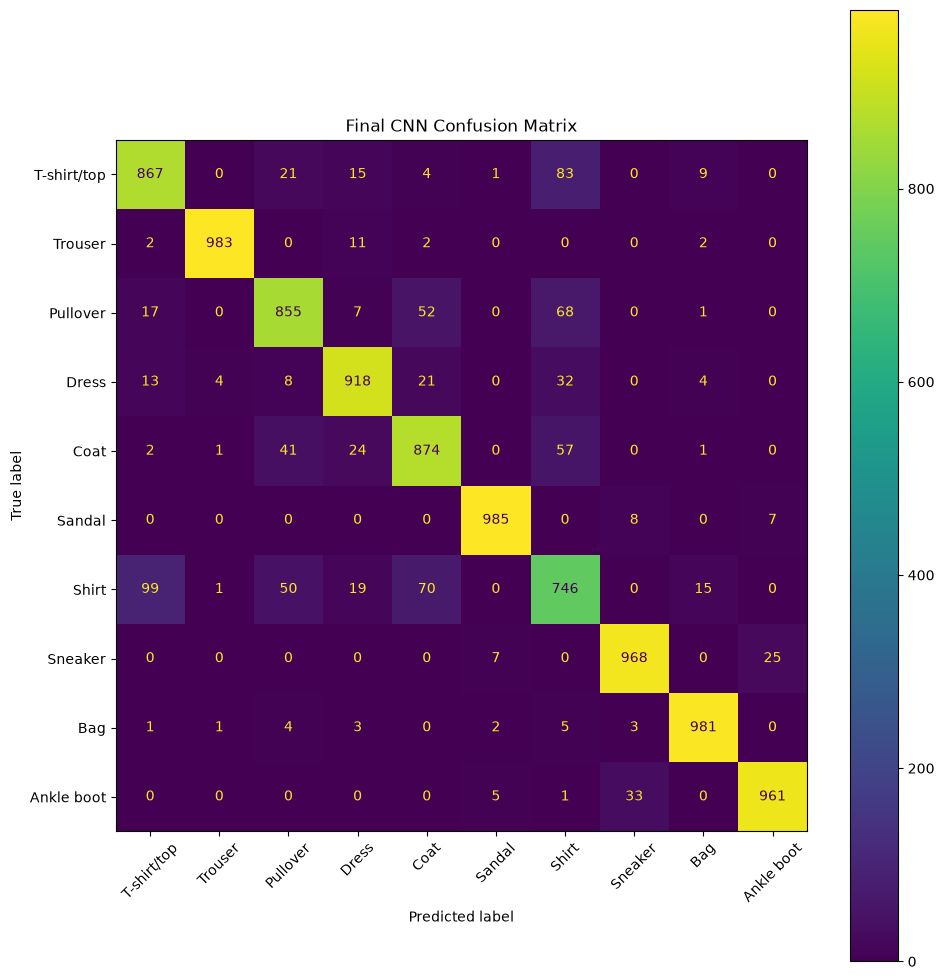

In [20]:
#Display confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

confusion = confusion_matrix(
    y_true,
    y_pred
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

display_matrix.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Final CNN Confusion Matrix")
plt.tight_layout()
plt.show()

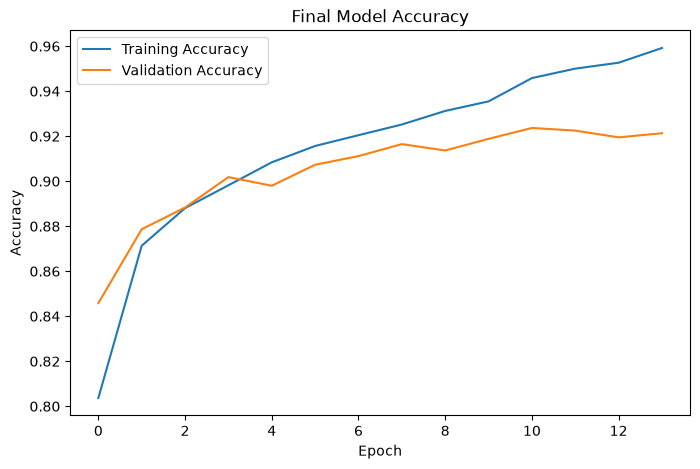

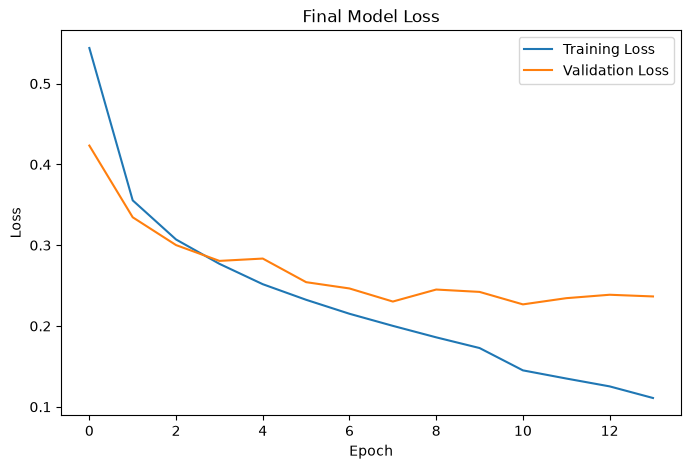

In [37]:
#Plot the final model's learning curves
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Model Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Loss")
plt.legend()
plt.show()

In [38]:
#Create the model-comparison table
import pandas as pd
from IPython.display import display, Markdown

# Confirm that all three models have been evaluated
required_variables = [
    "baseline_test_accuracy",
    "cnn_test_accuracy",
    "final_test_accuracy"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "Run the evaluation cells for all three models first. "
        f"Missing variables: {', '.join(missing_variables)}"
    )

# Convert decimal accuracy values to percentages
baseline_accuracy_pct = baseline_test_accuracy * 100
cnn_accuracy_pct = cnn_test_accuracy * 100
final_accuracy_pct = final_test_accuracy * 100

# Calculate improvement in percentage points relative to the baseline
cnn_improvement_pp = cnn_accuracy_pct - baseline_accuracy_pct
final_improvement_pp = final_accuracy_pct - baseline_accuracy_pct

# Calculate the final model's improvement over the simple CNN
final_vs_cnn_pp = final_accuracy_pct - cnn_accuracy_pct

# Determine the final model configuration
dropout_description = (
    "with Dropout"
    if best_use_dropout
    else "without Dropout"
)

final_characteristics = (
    f"Optimized CNN, {best_filters} initial filters, "
    f"{dropout_description}, learning-rate reduction"
)

# Create the comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline (Dense Layers)",
        "Simple CNN",
        "Final Model"
    ],
    "Accuracy": [
        f"{baseline_accuracy_pct:.2f}%",
        f"{cnn_accuracy_pct:.2f}%",
        f"{final_accuracy_pct:.2f}%"
    ],
    "Improvement": [
        "—",
        f"{cnn_improvement_pp:+.2f}pp",
        f"{final_improvement_pp:+.2f}pp"
    ],
    "Key Characteristics": [
        "Fully connected, no spatial feature learning",
        "Convolutional layers, learned spatial features",
        final_characteristics
    ]
})

print("Model Comparison")
display(model_comparison)

Model Comparison


,Model,Accuracy,Improvement,Key Characteristics
0,Baseline (Dense Layers),84.34%,—,"Fully connected, no spatial feature learning"
1,Simple CNN,91.02%,+6.68pp,"Convolutional layers, learned spatial features"
2,Final Model,91.38%,+7.04pp,"Optimized CNN, 32 initial filters, with Dropou..."


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**


The final model marginally outperforms the simple CNN by 0.36 percentage points through the addition of dropout regularization and optimized filter counts. While the improvement is modest, it validates the importance of preventing overfitting even in relatively simple architectures. The simple CNN alone captured the majority of available performance gain versus the baseline (~6.68% total improvement) through its convolutional architecture, indicating that the primary breakthrough came from learning spatial features rather than tuning regularization.

Future Experiments

To further improve performance on Fashion-MNIST, the following experiments can de performed:

- Deeper architectures: Construct 3–4 layer CNNs with progressively larger receptive fields to capture hierarchical features at multiple scales
- Batch normalization: Apply batch normalization between convolutional layers to stabilize training and potentially allow higher learning rates
- Data augmentation: Implement random rotations, shifts, and zooms during training to artificially expand the dataset and improve robustness
- Advanced optimization: Experiment with learning rate scheduling (e.g., cosine annealing) or optimizers like Adam with L2 weight decay to improve convergence
- Ensemble methods: Train multiple diverse CNN architectures and combine predictions via voting or averaging to potentially exceed individual model performance


🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.